# TP : Préparation de Données pour YOLO - Conversion Pascal VOC vers YOLOv11

Dans le domaine de la vision par ordinateur, il existe de nombreux formats d'annotation pour les tâches de détection d'objets : Pascal VOC, COCO, YOLO, TensorFlow Object Detection API, etc. Chaque framework ou bibliothèque privilégie souvent son propre format, optimisé pour ses besoins spécifiques.

En pratique, vous serez fréquemment amenés à convertir des datasets d'un format à un autre. Par exemple, un dataset public peut être distribué au format COCO ou Pascal VOC,  ou vous avez annoté vos propres données avec un outil qui exporte en Pascal VOC, mais vous souhaitez l'utiliser avec YOLO.

Ces conversions sont une étape courante et les maîtriser vous permettra de tirer parti de la diversité des datasets disponibles, indépendamment de leur format d'origine, et d'utiliser l'algorithme de détection de votre choix sans contrainte.

Ce TP vous guide dans la conversion d'un dataset d'annotations au format Pascal VOC vers le format YOLOv11.

Le format Pascal VOC utilise des coordonnées absolues en pixels pour les bounding boxes (xmin, ymin, xmax, ymax), tandis que YOLO nécessite des coordonnées normalisées relatives au centre (x_center, y_center, width, height). De plus, les deux formats diffèrent dans leur structure de fichiers : Pascal VOC utilise des fichiers XML pour les annotations, alors que YOLO utilise des fichiers texte (.txt), et leurs arborescences de dossiers sont également différentes.

Vous apprendrez à manipuler des fichiers d'annotations XML, à créer l'arborescence attendue par YOLO, à convertir les coordonnées des bounding boxes, et à générer le fichier de configuration YAML nécessaire à l'entraînement d'un modèle de détection d'objets YOLO.

Le dataset utilisé contient des images de pièces de monnaie américaines annotées au format Pascal VOC. L'objectif est de transformer ces annotations pour les rendre compatibles avec YOLOv11.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Préparer l'environnement logiciel

Importez l'ensemble des bibliothèques nécessaires pour ce TP :
- `cv2` pour la manipulation d'images
- `os` et `glob` pour la gestion des fichiers et chemins
- `xml.etree.ElementTree` pour parser les fichiers d'annotations XML au format Pascal VOC
- `matplotlib.pyplot` pour la visualisation
- `shutil` pour copier des fichiers
- `sklearn.preprocessing.LabelEncoder` pour encoder les classes sous forme d'identifiants numériques

In [2]:
import cv2
import os
import glob

import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

import shutil
import zipfile

from sklearn.preprocessing import LabelEncoder

## Exploration du dataset au format Pascal VOC

### Définir le chemin du dataset Pascal VOC

Définissez le chemin vers le répertoire contenant le dataset au format Pascal VOC.

In [ ]:
voc_dataset_dir = "/content/drive/MyDrive/computer_vision/td10"
zip_path="/content/drive/MyDrive/US-Coins.voc.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(voc_dataset_dir)
os.remove(zip_path)

### Visualiser une annotation Pascal VOC

Implémentez la fonction `visualize_pascal_voc_annotation(data_dir, index=0)` qui permet de visualiser une image avec ses bounding boxes annotées. Cette fonction doit :
- Lister les fichiers d'annotations XML présents dans `data_dir` et sélectionner celui correspondant à l'indice `index`
- Parser le fichier XML avec `xml.etree.ElementTree` pour extraire le nom de l'image et les bounding boxes
- Charger l'image avec `cv2`
- Parcourir tous les objets annotés (`root.findall('object')`) pour extraire les coordonnées de chaque bounding box (`xmin`, `ymin`, `xmax`, `ymax`) et le label associé
- Dessiner les rectangles sur l'image avec `cv2.rectangle()` en vert, et ajouter les labels avec `cv2.putText()`
- Afficher l'image annotée avec `matplotlib` en ajoutant un titre avec le nom du fichier

In [4]:
def visualize_pascal_voc_annotation(data_dir, index=0):
    """
    Visualize an image with its bounding box annotations.

    Args:
        data_dir: Path to the data directory
        index: Index of the annotation file to visualize (default: 0)
    """

    # Récupérer le fichier d'annotation à l'index spécifié
    annotation_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.xml')])
    annotation_file = os.path.join(data_dir, annotation_files[index])

    # Parser le fichier XML
    tree = ET.parse(annotation_file)
    root = tree.getroot()

    # Obtenir le nom du fichier image
    image_filename = root.find('filename').text
    image_path = os.path.join(data_dir, image_filename)

    # Lire l'image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Dessiner les boîtes englobantes
    for obj in root.findall('object'):
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        label = obj.find('name').text

        # Dessiner le rectangle
        cv2.rectangle(image,(xmin,ymin),(xmax,ymax),(0, 255, 0), 2)
        cv2.putText(image, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Afficher l'image
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Image: {image_filename}')
    plt.show()

### Tester la visualisation sur un exemple

Testez la fonction `visualize_pascal_voc_annotation()` sur un exemple du dataset d'entraînement :
- Définissez un indice (par exemple `num = 37` parcequ'elle est jolie :) )
- Construisez le chemin vers le dossier `train`
- Appelez la fonction de visualisation pour afficher l'image annotée correspondante

Num: 37


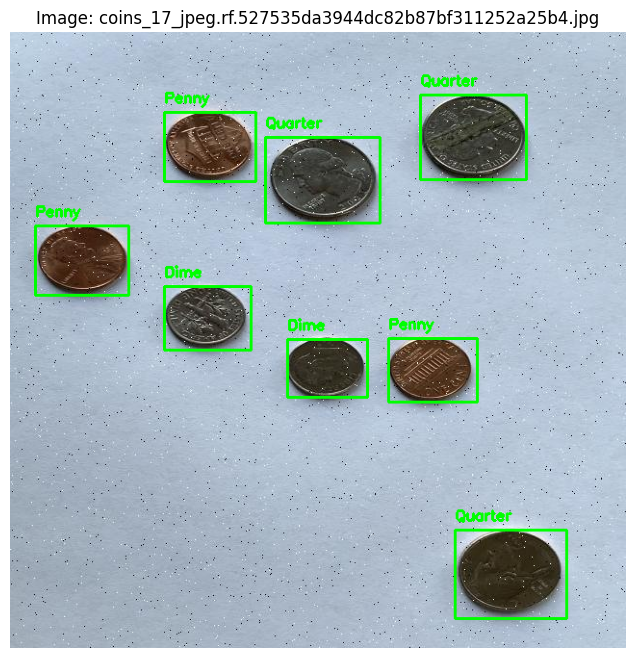

In [5]:
num = 37
scr_dir = os.path.join(voc_dataset_dir+"/US-Coins.voc", "train")
print(f"Num: {num}")
visualize_pascal_voc_annotation(scr_dir,num)

## Conversion vers YOLO

Pour obtenir un dataset au format YOLO, nous allons créer l'arborescence de fichier suivante :

<pre><code><small>../data/US-Coins.yolov11/
├── US-Coins.yaml
├── test/
│   ├── images/
│   │       [5 files (.jpg)]
│   └── labels/
│           [5 files (.txt)]
├── train/
│   ├── images/
│   │       [105 files (.jpg)]
│   └── labels/
│           [105 files (.txt)]
└── valid/
    ├── images/
    │       [10 files (.jpg)]
    └── labels/
            [10 files (.txt)]
</small></code></pre>

### Créer l'arborescence de dossiers pour YOLO

Définissez le chemin de destination `yolo_dir` (par exemple `"../data/US-Coins.yolov11"`), puis créez l'arborescence de dossiers attendue par YOLOv11 :
- Définissez une liste `yolo_splits` contenant les trois splits (`["train", "valid", "test"]`)
- Définissez une liste `yolo_sub_dirs` contenant les deux sous-dossiers (`["images", "labels"]`)
- Parcourez ces listes avec des boucles imbriquées pour créer tous les dossiers nécessaires avec `os.makedirs()` et l'option `exist_ok=True`

In [6]:
yolo_dir = "/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11"
yolo_splits = ["train", "valid", "test"]
yolo_sub_dirs = ["images", "labels"]

print("Dossiers YOLO créés :")
for ys in yolo_splits:
  os.makedirs(f"{yolo_dir}/{ys}",exist_ok=True)
  for ysd in yolo_sub_dirs:
    os.makedirs(f"{yolo_dir}/{ys}/{ysd}",exist_ok=True)
    print(f"{yolo_dir}/{ys}/{ysd}")


Dossiers YOLO créés :
/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/images
/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/labels
/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/valid/images
/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/valid/labels
/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/images
/content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/test/labels


### Extraire la liste des classes du dataset

Pour construire les annotations YOLO, il est nécessaire de connaître l'ensemble complet des classes présentes dans le dataset :

- Parcourez tous les fichiers d'annotations XML du dossier `train` avec `glob`
- Pour chaque fichier, parsez-le avec `xml.etree.ElementTree`
- Extrayez les noms de classes (balise `name` dans chaque `object`)
- Stockez ces noms dans un ensemble (`set`) pour éviter les doublons
- Convertissez l'ensemble en liste triée alphabétiquement
- Affichez cette liste de classes pour vérification

In [7]:
scr_dir = os.path.join(voc_dataset_dir+"/US-Coins.voc", "train")

annotation_files =  glob.glob(f"{scr_dir}/*.xml")
all_classes = set()
for annotation_file in annotation_files:
    tree = ET.parse(annotation_file)
    root = tree.getroot()
    for obj in root.findall('object'):
            bbox = obj.find('bndbox')
            # xmin = int(bbox.find('xmin').text)
            # ymin = int(bbox.find('ymin').text)
            # xmax = int(bbox.find('xmax').text)
            # ymax = int(bbox.find('ymax').text)
            label = obj.find('name').text
            all_classes.add(label)

all_classes = sorted(list(all_classes))
print(f"Classes trouvées : {all_classes}")

Classes trouvées : ['Dime', 'Nickel', 'Penny', 'Quarter']


### Créer l'encodeur de labels pour YOLO

Le format YOLO nécessite d'encoder les noms de classes sous forme d'identifiants numériques entiers (0, 1, 2, etc.).

- Créez un `LabelEncoder` de scikit-learn
- Entraînez-le sur la liste des classes `all_classes`
- Construisez un dictionnaire `yolo_label_enc` qui associe chaque nom de classe à son identifiant numérique
- Affichez ce mapping pour vérifier la correspondance entre les noms de classes et leurs encodages numériques, qui sera utilisé lors de la conversion des annotations

In [8]:
# Créer le label encoder pour YOLO
label_encoder = LabelEncoder()
label_encoder.fit(all_classes)
yolo_label_enc=dict({})

# Petit rappel d'utilisation du label encoder
print(f"Label encoder mapping:")
encoded_values=label_encoder.transform(all_classes)
for label,encoded in zip(all_classes,encoded_values):
    encoded_value = encoded
    yolo_label_enc[encoded]=label
    print(f"  {label}: {encoded_value}")

print(yolo_label_enc)

Label encoder mapping:
  Dime: 0
  Nickel: 1
  Penny: 2
  Quarter: 3
{np.int64(0): 'Dime', np.int64(1): 'Nickel', np.int64(2): 'Penny', np.int64(3): 'Quarter'}


### Convertir une annotation Pascal VOC vers le format YOLO

Implémentez la fonction `voc_to_yolo(annotation_file, yolo_dest_dir, verbose=True)` qui convertit un fichier d'annotation Pascal VOC (.xml) vers le format YOLO. Cette fonction doit effectuer les opérations suivantes :

- Parser le fichier XML pour extraire le nom de l'image et charger celle-ci avec `cv2` afin de récupérer ses dimensions (largeur, hauteur)
- Copier l'image source vers le sous-dossier `images` de `yolo_dest_dir` avec `shutil`
- Parcourir tous les objets annotés pour extraire les bounding boxes au format Pascal VOC (coordonnées absolues : `xmin`, `ymin`, `xmax`, `ymax`)
- Convertir chaque bounding box vers le format YOLO normalisé :
  - Normaliser les coordonnées pour obtenir des valeurs dans [0, 1]
  - Calculer le centre de la box
  - Calculer les dimensions de la box
  - Encoder le label avec `label_encoder` pour obtenir l'identifiant numérique de la classe
- Formater chaque annotation YOLO sous forme de ligne : `"<class_id> <x_center> <y_center> <width> <height>"` avec 7 décimales de précision
- Écrire toutes les lignes d'annotations dans un fichier texte (`.txt`) dans le sous-dossier `labels` de `yolo_dest_dir`, en utilisant le même nom de base que l'image
- Retourner un tuple contenant les chemins du fichier image et du fichier label créés

NB : Si `verbose=True`, afficher au fur et à mesure les informations de traitement (fichiers source/destination, dimensions, annotations)

Testez ensuite cette fonction sur un fichier d'annotation échantillon (par exemple `annotation_files[num]`) en mode verbose pour vérifier la conversion.

In [14]:
def voc_to_yolo(annotation_file, yolo_dest_dir, verbose=True):
    """
        Convert a Pascal VOC annotation file to YOLO format.

        Args:
            annotation_file: Path to the Pascal VOC XML annotation file
            yolo_dest_dir: Destination directory for YOLO format (should contain 'images' and 'labels' subdirectories)
            verbose: If True, print detailed processing information (default: True)

        Returns:
            tuple: (path to copied image file, path to created YOLO label file)
        """


    if verbose:
        print(f"Processing annotation file: {annotation_file}")
        print("Yolo label data")

    # Parser le fichier XML
    tree = ET.parse(annotation_file)
    root = tree.getroot()

    # Obtenir le nom du fichier image
    image_filename = root.find('filename').text
    image_path = annotation_file.replace(".xml",'.jpg')

    copy_path=shutil.copy(image_path,yolo_dest_dir+"/images",follow_symlinks=False)

    # Lire l'image
    image = cv2.imread(image_path)
    label_path=os.path.join(yolo_dest_dir,"labels",image_filename.replace('.jpg','.txt'))
    if copy_path and verbose:
      print(f"Image file:{image_path}")
      print(f"Image dimensions: width={image.shape[0]}, heigth={image.shape[1]}")
      print(f"Image copied to:{copy_path}")

    with open(label_path,'w') as file:
      # Dessiner les boîtes englobantes
      for obj in root.findall('object'):
          tmp=""
          bbox = obj.find('bndbox')
          xmin = int(bbox.find('xmin').text)
          ymin = int(bbox.find('ymin').text)
          xmax = int(bbox.find('xmax').text)
          ymax = int(bbox.find('ymax').text)
          label = obj.find('name').text
          tmp=f"{label_encoder.transform([label])[0]}\t{((xmin+xmax)/(2*image.shape[0])):.4f}\t{((ymin+ymax)/(2*image.shape[1])):.4f}\t{((xmax-xmin)/image.shape[0]):.4f}\t{((ymax-ymin)/image.shape[1]):.4f}\n"
          if verbose:
            print(tmp)
          file.write(tmp)
    return f"{yolo_dest_dir}/images/{image_filename}",label_path


# Test de la fonction avec un seul fichier
sample_file = annotation_files[num]
yolo_image, yolo_label = voc_to_yolo(sample_file, os.path.join(yolo_dir, "train"), verbose=False)
print(f"YOLO image file: {yolo_image}")
print(f"YOLO label file: {yolo_label}")

YOLO image file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/images/coins_43_jpeg.rf.14da580329324686576d6e4100e2138d.jpg
YOLO label file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/labels/coins_43_jpeg.rf.14da580329324686576d6e4100e2138d.txt


### Convertir tous les fichiers pour chaque split

Implémentez la fonction utilitaire `all_to_YOLO(scr_dir, dest_dir)` qui applique la conversion YOLO à l'ensemble des fichiers d'annotations d'un répertoire source :
- Lister tous les fichiers XML du dossier source
- Appeler `voc_to_yolo()` pour chaque fichier en mode non-verbose (`verbose=False`)

Appelez ensuite cette fonction trois fois pour convertir les trois splits du dataset : `train`, `valid` et `test`

Cette étape génère l'ensemble des images et fichiers d'annotations au format YOLO dans l'arborescence créée précédemment.

In [16]:
# Conversion de tous les fichiers d'annotations pour chaque split

def all_to_YOLO(scr_dir, dest_dir):
    """
        Convert all Pascal VOC annotation files in a directory to YOLO format.

        Args:
            scr_dir: Source directory containing Pascal VOC XML annotation files
            dest_dir: Destination directory for YOLO format (should contain 'images' and 'labels' subdirectories)
        """
    annotation_files =  glob.glob(f"{scr_dir}/*.xml")
    for af in annotation_files:
      yolo_image, yolo_label=voc_to_yolo(af,dest_dir,False)
      print(f"YOLO image file: {yolo_image}")
      print(f"YOLO label file: {yolo_label}")

all_to_YOLO(os.path.join(voc_dataset_dir+"/US-Coins.voc", "train"), os.path.join(yolo_dir, "train"))
all_to_YOLO(os.path.join(voc_dataset_dir+"/US-Coins.voc", "valid"), os.path.join(yolo_dir, "valid"))
all_to_YOLO(os.path.join(voc_dataset_dir+"/US-Coins.voc", "test"), os.path.join(yolo_dir, "test"))

YOLO image file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/images/coins_50_jpeg.rf.d3734b846cf1ec782c0578ee069990d7.jpg
YOLO label file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/labels/coins_50_jpeg.rf.d3734b846cf1ec782c0578ee069990d7.txt
YOLO image file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/images/coins_31_jpeg.rf.9096a7c267e3a39e2b103f5a4d291728.jpg
YOLO label file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/labels/coins_31_jpeg.rf.9096a7c267e3a39e2b103f5a4d291728.txt
YOLO image file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/images/coins_33_jpeg.rf.9984bf804b00bc688f9acfd95d2aa366.jpg
YOLO label file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/labels/coins_33_jpeg.rf.9984bf804b00bc688f9acfd95d2aa366.txt
YOLO image file: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/train/images/coin

### Créer le fichier de configuration YAML pour YOLOv11

Générez le fichier de configuration YAML (`US-Coins.yaml`) nécessaire à l'entraînement d'un modèle YOLOv11. Ce fichier doit être placé à la racine du dataset YOLO (`yolo_dir`) et contenir les informations suivantes :

- Les chemins relatifs vers les dossiers d'images pour chaque split : `train: train/images`, `val: valid/images`, `test: test/images`
- Le nombre de classes `nc` (nombre d'éléments dans `all_classes`)
- La liste des noms de classes `names` au format liste Python, dans l'ordre correspondant à l'encodage du `label_encoder` (classes triées alphabétiquement)

Écrivez ce fichier ligne par ligne avec les instructions `write()` appropriées, en formatant correctement la liste des classes entre crochets avec des virgules séparatrices. Dans notre cas, le fichier doit contenir :
<pre><code><small>train: train/images
val: valid/images
test: test/images

nc: 4
names: ['Dime', 'Nickel', 'Penny', 'Quarter']
</small></code></pre>


Affichez ensuite le contenu du fichier YAML généré pour vérification. Ce fichier sera utilisé par YOLO pour connaître la structure du dataset lors de l'entraînement.

In [22]:
# Création du fichier YAML de configuration YOLOv11 à partir des données extraites
# (On le place cette fois-ci dans le dossier du dataset)

yaml_file = os.path.join(yolo_dir, "US-Coins.yaml")




with open(yaml_file, 'w') as f:
  # f.write(f"path: {yolo_dir}\n")
  f.write(f"train: train/images\n")
  f.write(f"val: val/images\n")
  f.write(f"test: test/images\n\n")
  f.write(f"nc: {len(all_classes)}\n")
  f.write(f"names: {all_classes}")
  f.close()



print(f"YOLOv11 configuration file created at: {yaml_file}")
print("-"*80)
with open(yaml_file, 'r') as f:
    print(f.read())

YOLOv11 configuration file created at: /content/drive/MyDrive/computer_vision/td10/data/US-Coins.yolov11/US-Coins.yaml
--------------------------------------------------------------------------------
train: train/images
val: val/images
test: test/images

nc: 4
names: ['Dime', 'Nickel', 'Penny', 'Quarter']
